In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os
import sys

if os.getcwd().endswith('notebooks'):
    os.chdir('..')
sys.path.append(os.getcwd())

FILE_PATH = "/content/drive/MyDrive/REXIA/data/all_data_with_identities.csv"

def load_data(file_path=FILE_PATH):
    df = pd.read_csv(file_path)
    return df

# Analyse des longueurs et de la distribution de `toxicity`

Ce notebook calcule les statistiques de longueur des textes, compare les longueurs entre textes toxiques et non-toxiques, examine l'équilibre du dataset et commente la distribution continue de la colonne `toxicity`.

In [7]:
# Charger les données et préparer la colonne de longueur
df = load_data()
df['comment_text'] = df['comment_text'].fillna('')
df['text_length'] = df['comment_text'].str.len()
threshold = 0.5
df['is_toxic'] = (df['toxicity'] >= threshold).astype(int)

#keep only id, comment_text, male, female, homosexual_gay_or_lesbian, black, white, na_gender, na_orientation, na_race, toxicity
cols_to_keep = ['id', 'comment_text', 'male', 'female', 'homosexual_gay_or_lesbian', 'black', 'white', 'na_gender', 'na_orientation', 'na_race', 'text_length', 'toxicity','is_toxic']
df = df[cols_to_keep].copy()



print('Shape:', df.shape)



Shape: (448000, 13)


In [8]:
df.head(10)

,id,comment_text,male,female,homosexual_gay_or_lesbian,black,white,na_gender,na_orientation,na_race,text_length,toxicity,is_toxic
0,627762,OH yes - Were those evil Christian Missionarie...,0.0,0.0,0.0,0.0,0.00,1,1,1,253,0.800000,1
1,5892815,Why is this black racist crap still on the G&M...,0.0,0.0,0.0,1.0,0.75,1,1,0,688,0.757143,1
2,416437,even up here.......BLACKS!,0.0,0.0,0.0,1.0,0.00,1,1,0,26,0.688525,1
3,5137126,Blame men. There's always an excuse to blame ...,1.0,1.0,0.0,0.0,0.00,0,1,1,76,0.545455,1
4,855753,And the woman exposing herself saying grab thi...,0.0,1.0,0.0,0.0,0.00,0,1,1,165,0.728571,1
5,379144,You have no business making any comments on th...,0.0,0.0,0.0,0.0,0.00,1,1,1,484,0.594595,1
6,377096,"""Let's get the black folks and the white folks...",0.0,0.0,0.0,1.0,1.00,1,1,0,71,0.736842,1
7,641883,I guess the issue is people not willing to put...,0.0,0.0,0.0,0.0,0.00,1,1,1,135,0.764706,1
8,5218990,"JackJohnson5:\n""And they say Trump supporters ...",0.0,0.0,0.0,0.0,0.00,1,1,1,270,1.000000,1
9,5483824,Trump could accidently push a button and Canad...,0.0,0.0,0.0,0.0,0.00,1,1,1,153,0.421875,0


In [9]:
# Statistiques descriptives des longueurs (min, max, mean, median, percentiles)
length_stats = df['text_length'].describe(percentiles=[0.01,0.05,0.25,0.5,0.75,0.9,0.95,0.99])
length_stats_df = length_stats.to_frame(name='value')
length_stats_df.loc['variance'] = df['text_length'].var()
length_stats_df

,value
count,448000.000000
mean,351.742944
std,289.323733
min,0.000000
1%,15.000000
5%,39.000000
25%,121.000000
50%,257.000000
75%,512.000000
90%,872.000000


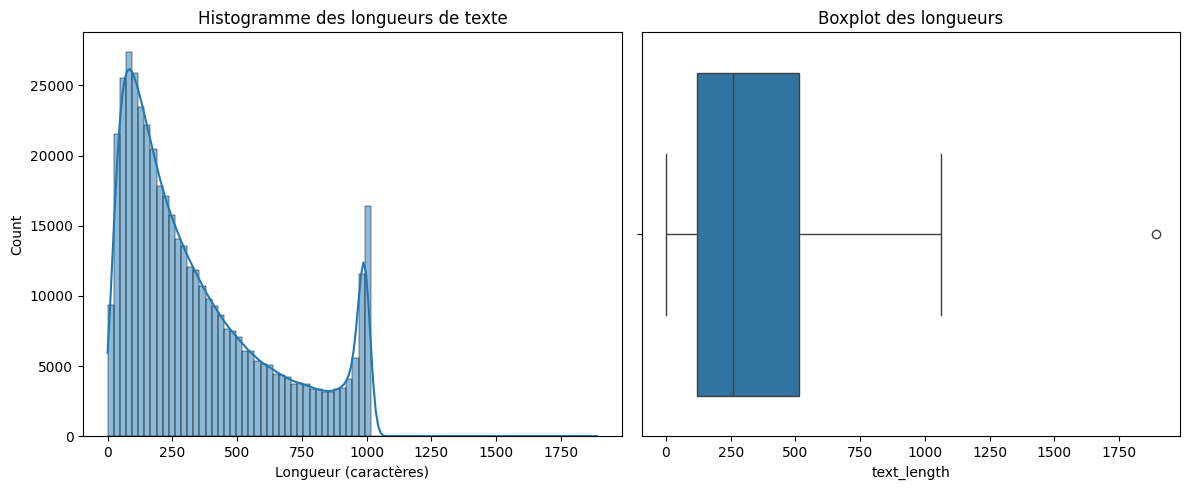

In [10]:
# Histogramme et boxplot de la distribution des longueurs
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df['text_length'], bins=80, kde=True)
plt.title('Histogramme des longueurs de texte')
plt.xlabel('Longueur (caractères)')
plt.subplot(1,2,2)
sns.boxplot(x=df['text_length'])
plt.title('Boxplot des longueurs')
plt.tight_layout()
plt.show()

## Distribution des longueurs par classe toxique / non-toxique

On crée une classe binaire `is_toxic` en se basant sur un seuil de `toxicity >= 0.5`. Vous pouvez ajuster le seuil si nécessaire.

In [11]:
# Définir la classe binaire (seuil 0.5) et vérifier l'équilibre

counts = df['is_toxic'].value_counts().sort_index()
percent = df['is_toxic'].value_counts(normalize=True).sort_index() * 100
balance_df = pd.DataFrame({'count': counts, 'percent': percent})
balance_df.index = ['non_toxic','toxic']
balance_df

,count,percent
non_toxic,397206,88.662054
toxic,50794,11.337946


### Équilibre du jeu de données
Le dataset présente un **déséquilibre de classe important** :
* **Non-toxiques :** 88,66 %
* **Toxiques :** 11,33 %

Ce déséquilibre (ratio d'environ 1 pour 8) implique que l'Accuracy ne sera pas un indicateur de performance pertinent. Un modèle "naïf" prédisant systématiquement la classe majoritaire obtiendrait un score élevé sans pour autant détecter la toxicité. Il sera crucial de surveiller le **F1-Score** ou l'**AUC-ROC** lors de l'entraînement.

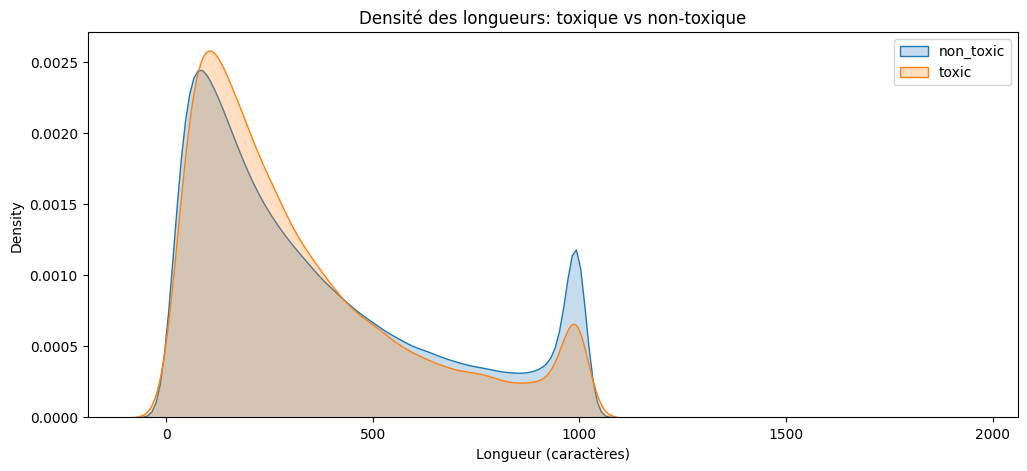

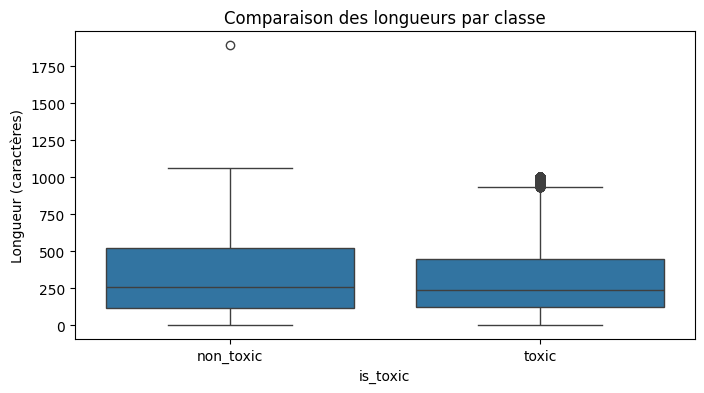

In [12]:
# Distribution des longueurs pour les deux classes
plt.figure(figsize=(12,5))
sns.kdeplot(df.loc[df['is_toxic']==0,'text_length'], label='non_toxic', fill=True, bw_adjust=1)
sns.kdeplot(df.loc[df['is_toxic']==1,'text_length'], label='toxic', fill=True, bw_adjust=1)
plt.legend()
plt.xlabel('Longueur (caractères)')
plt.title('Densité des longueurs: toxique vs non-toxique')
plt.show()
# Boxplot comparatif
plt.figure(figsize=(8,4))
sns.boxplot(x='is_toxic', y='text_length', data=df)
plt.xticks([0,1], ['non_toxic','toxic'])
plt.ylabel('Longueur (caractères)')
plt.title('Comparaison des longueurs par classe')
plt.show()

### Analyse des longueurs (Toxique vs Non-Toxique)
L'observation de la densité et des Boxplots permet de dégager plusieurs points clés :

* **Similarité de structure :** Les distributions des deux classes se superposent largement. La majorité des textes sont courts, avec un pic de fréquence entre **0 et 250 caractères**.
* **Effet de seuil :** On note un second pic marqué aux alentours de **1000 caractères**. Cela suggère une contrainte technique (limite de caractères de la plateforme source) plutôt qu'un comportement naturel d'écriture.
* **Comportement de la classe toxique :** La densité des commentaires toxiques est légèrement plus élevée pour les messages très courts. À l'inverse, les commentaires non-toxiques présentent davantage de valeurs extrêmes (outliers) au-delà de 1000 caractères, suggérant que les messages très longs sont plus rarement classés comme toxiques.

## Commentaires automatiques sur l'équilibre et la distribution de `toxicity`

,value
n_samples,448000.000000
n_missing_comments,0.000000
tox_mean,0.140029
tox_median,0.000000
tox_std,0.218396
tox_skew,1.641299
tox_kurtosis,1.955947
tox_min,0.000000
tox_max,1.000000


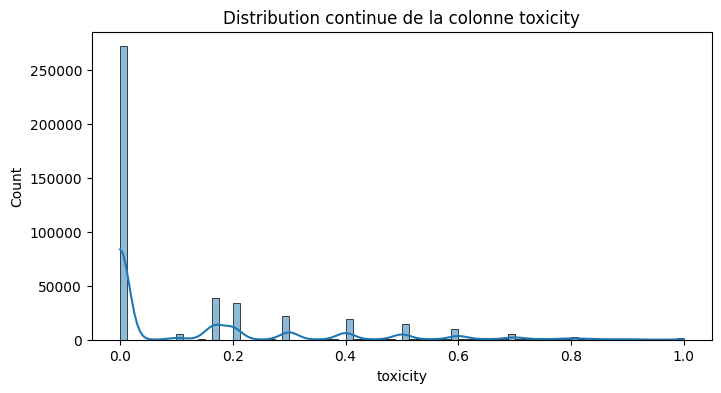

Commentaires:
- Echantillons: 448000
- Moyenne toxicity: 0.1400, médiane: 0.0000, écart-type: 0.2184
- La distribution de `toxicity` est fortement asymétrique (skewness > 1).
Equilibre (seuil 0.5) :
            count    percent
non_toxic  397206  88.662054
toxic       50794  11.337946


In [13]:
# Observations automatiques
from scipy.stats import skew, kurtosis
tox = df['toxicity'].dropna()
obs = {}
obs['n_samples'] = len(df)
obs['n_missing_comments'] = df['comment_text'].isna().sum()
obs['tox_mean'] = tox.mean()
obs['tox_median'] = tox.median()
obs['tox_std'] = tox.std()
obs['tox_skew'] = skew(tox) if len(tox)>0 else float('nan')
obs['tox_kurtosis'] = kurtosis(tox) if len(tox)>0 else float('nan')
obs['tox_min'] = tox.min()
obs['tox_max'] = tox.max()
obs_df = pd.Series(obs).to_frame('value')
display(obs_df)
# Histogramme de la colonne toxicity
plt.figure(figsize=(8,4))
sns.histplot(tox, bins=80, kde=True)
plt.title('Distribution continue de la colonne toxicity')
plt.xlabel('toxicity')
plt.show()
# Quelques commentaires textuels basés sur chiffres
print('Commentaires:')
print(f"- Echantillons: {obs['n_samples']}")
print(f"- Moyenne toxicity: {obs['tox_mean']:.4f}, médiane: {obs['tox_median']:.4f}, écart-type: {obs['tox_std']:.4f}")
if abs(obs['tox_skew'])>1:
    print('- La distribution de `toxicity` est fortement asymétrique (skewness > 1).')
elif abs(obs['tox_skew'])>0.5:
    print('- La distribution de `toxicity` montre une asymétrie modérée.')
else:
    print('- La distribution de `toxicity` est proche de la symétrie.')
# Équilibre selon seuil
print('Equilibre (seuil 0.5) :')
print(balance_df.to_string())

### Distribution de la variable cible (Toxicity)
La variable `toxicity` étant un score continu entre 0 et 1, sa distribution révèle la nature du processus d'annotation :

* **Prédominance du neutre :** Une immense majorité des données se concentre à la valeur **0.0**, confirmant la rareté relative des contenus problématiques.
* **Nature discrète des scores :** La distribution présente des "pics" réguliers (ex: 0.16, 0.2, 0.33, 0.5). Cela s'explique par le calcul du score : il s'agit du ratio d'annotateurs ayant jugé le texte toxique (par exemple, 1 annotateur sur 6 donne 0.166).
* **Concentration autour du seuil :** Très peu de commentaires font l'unanimité (score de 1.0). La plupart des contenus classés comme toxiques se situent dans la zone **[0.5 - 0.7]**, ce qui souligne la subjectivité inhérente à la détection de la toxicité.

## Prétraitement et Visualisation

### Nettoyage

In [14]:
import re
import string

def clean_text(text):
    """Nettoie un commentaire : minuscules, suppression URL/mentions/ponctuation excessive."""
    text = str(text).lower()
    # Suppression des URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    # Suppression des mentions utilisateurs (@username)
    text = re.sub(r'@\w+', '', text)
    # Suppression des balises HTML résiduelles
    text = re.sub(r'<[^>]+>', '', text)
    # Suppression des caractères répétés (ex: "!!!" → "!")
    text = re.sub(r'([!?.]){2,}', r'\1', text)
    # Suppression de la ponctuation sauf apostrophes
    text = re.sub(r"[^\w\s']", ' ', text)
    # Suppression des espaces multiples
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['cleaned_text'] = df['comment_text'].apply(clean_text)

# Aperçu avant / après nettoyage
print("=== Exemples avant / après nettoyage ===")
for i in df.sample(3, random_state=42).index:
    print(f"\n[AVANT] {df.loc[i, 'comment_text'][:120]}")
    print(f"[APRÈS] {df.loc[i, 'cleaned_text'][:120]}")


=== Exemples avant / après nettoyage ===

[AVANT] Thank you Stephanie, great post. You should be very proud of your family.
[APRÈS] thank you stephanie great post you should be very proud of your family

[AVANT] Poor, poor us! We're so abused! Give it a break, men continue to dominate most societies.
[APRÈS] poor poor us we're so abused give it a break men continue to dominate most societies

[AVANT] Yeah, as we've gotten so used to with the Rockies year after year, there's a lot of preseason hype that just doesn't tur
[APRÈS] yeah as we've gotten so used to with the rockies year after year there's a lot of preseason hype that just doesn't turn 


=== Distribution du nombre de tokens par commentaire ===
count    448000.0
mean         62.0
std          50.6
min           0.0
5%            7.0
25%          22.0
50%          46.0
75%          90.0
95%         169.0
99%         184.0
max         314.0
Name: n_tokens, dtype: float64


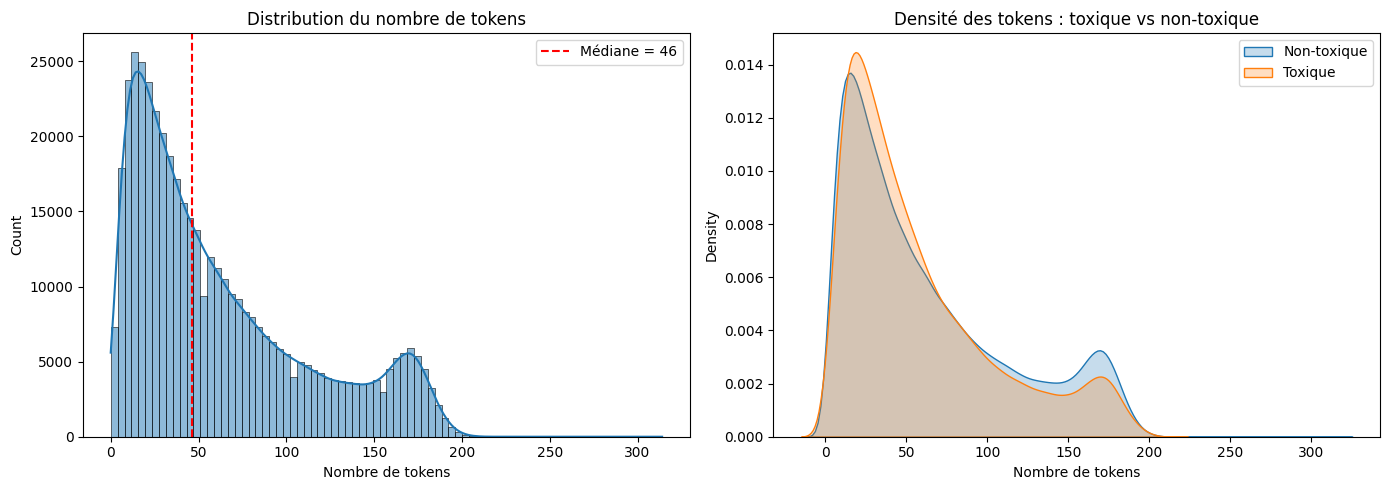

In [15]:
import nltk
from nltk.tokenize import word_tokenize

# Télécharger les ressources NLTK nécessaires (silencieux si déjà présentes)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

# Tokenisation
df['tokens'] = df['cleaned_text'].apply(word_tokenize)
df['n_tokens'] = df['tokens'].apply(len)

# Statistiques de la distribution du nombre de tokens
print("=== Distribution du nombre de tokens par commentaire ===")
print(df['n_tokens'].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).round(1))

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['n_tokens'], bins=80, kde=True, ax=axes[0])
axes[0].set_title('Distribution du nombre de tokens')
axes[0].set_xlabel('Nombre de tokens')
axes[0].axvline(df['n_tokens'].median(), color='red', linestyle='--', label=f"Médiane = {df['n_tokens'].median():.0f}")
axes[0].legend()

sns.kdeplot(df.loc[df['is_toxic']==0, 'n_tokens'], label='Non-toxique', fill=True, ax=axes[1])
sns.kdeplot(df.loc[df['is_toxic']==1, 'n_tokens'], label='Toxique', fill=True, ax=axes[1])
axes[1].set_title('Densité des tokens : toxique vs non-toxique')
axes[1].set_xlabel('Nombre de tokens')
axes[1].legend()

plt.tight_layout()
plt.show()


### Lemmatisation

In [17]:
from nltk.stem import WordNetLemmatizer
import nltk

nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    """Lemmatise une liste de tokens (noun par défaut, sans POS tagging pour la performance)."""
    return [lemmatizer.lemmatize(word) for word in tokens]

df['lemmas'] = df['tokens'].apply(lemmatize_tokens)
df['lemmatized_text'] = df['lemmas'].apply(lambda toks: ' '.join(toks))

# Aperçu : tokens bruts vs lemmes
print("=== Comparaison tokens / lemmes (3 exemples) ===")
for i in df.sample(3, random_state=7).index:
    tokens_preview = df.loc[i, 'tokens'][:12]
    lemmas_preview = df.loc[i, 'lemmas'][:12]
    print(f"\n[TOKENS] {tokens_preview}")
    print(f"[LEMMES] {lemmas_preview}")

# Impact sur la taille du vocabulaire
vocab_tokens = set(t for toks in df['tokens'] for t in toks)
vocab_lemmas  = set(l for lems in df['lemmas']  for l in lems)
print(f"\nVocabulaire avant lemmatisation : {len(vocab_tokens):,} formes")
print(f"Vocabulaire après lemmatisation : {len(vocab_lemmas):,} formes")
print(f"Réduction : {(1 - len(vocab_lemmas)/len(vocab_tokens))*100:.1f} %")

=== Comparaison tokens / lemmes (3 exemples) ===

[TOKENS] ['historical', 'catholicism', 'the', 'best', 'history', 'you', 'can', 'read', 'the', 'butchery', 'the', 'salacious']
[LEMMES] ['historical', 'catholicism', 'the', 'best', 'history', 'you', 'can', 'read', 'the', 'butchery', 'the', 'salacious']

[TOKENS] ['you', 'know', 'following', 'the', 'broncos', 'and', 'commenting', 'on', 'denver', 'used', 'to', 'be']
[LEMMES] ['you', 'know', 'following', 'the', 'bronco', 'and', 'commenting', 'on', 'denver', 'used', 'to', 'be']

[TOKENS] ['no', 'i', 'simply', 'state', 'that', 'an', 'ex', 'priest', 'has', 'no', 'validity', 'or']
[LEMMES] ['no', 'i', 'simply', 'state', 'that', 'an', 'ex', 'priest', 'ha', 'no', 'validity', 'or']

Vocabulaire avant lemmatisation : 158,811 formes
Vocabulaire après lemmatisation : 146,368 formes
Réduction : 7.8 %


### Nuage de mots toxiques / non toxiques

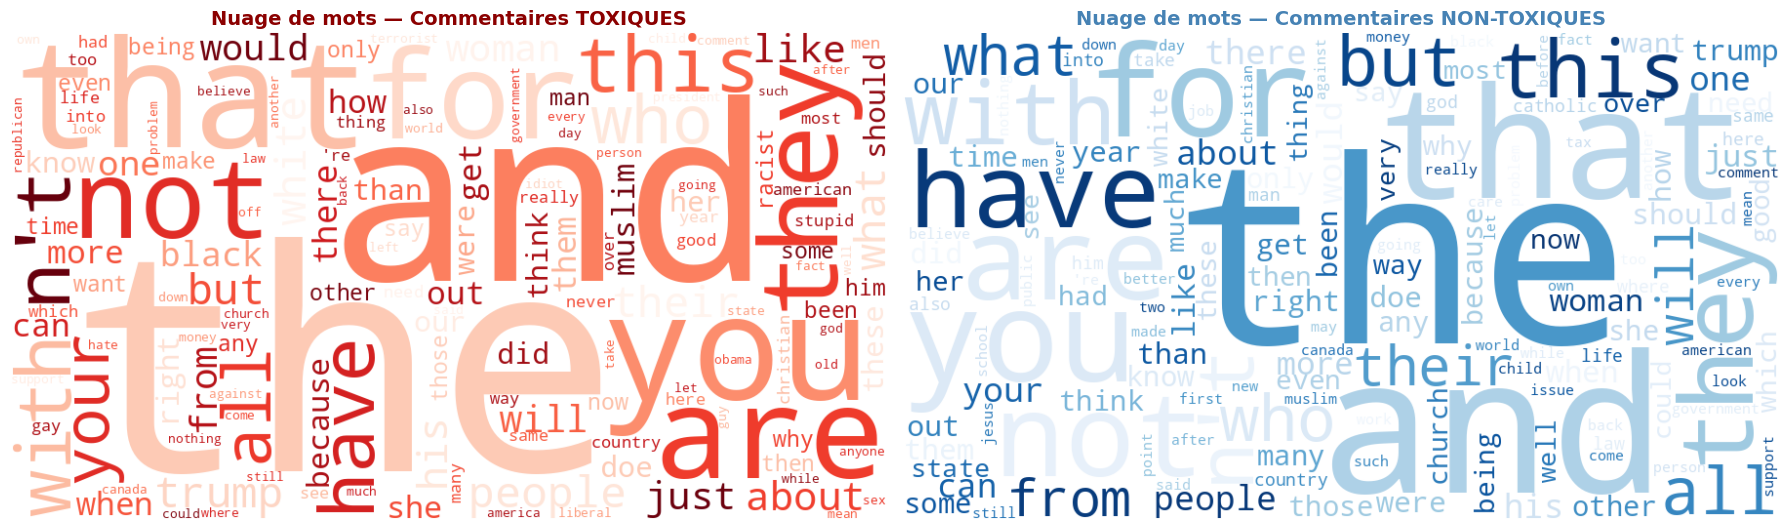

In [18]:
try:
    from wordcloud import WordCloud
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'wordcloud', '-q'], check=True)
    from wordcloud import WordCloud

from collections import Counter

def build_freq(mask_series, lemmas_series):
    """Fréquence des lemmes pour un sous-ensemble du DataFrame."""
    all_lemmas = [w for toks in lemmas_series[mask_series] for w in toks if len(w) > 2]
    return Counter(all_lemmas)

mask_toxic     = df['is_toxic'] == 1
mask_non_toxic = df['is_toxic'] == 0

freq_toxic     = build_freq(mask_toxic,     df['lemmas'])
freq_non_toxic = build_freq(mask_non_toxic, df['lemmas'])

wc_toxic = WordCloud(
    width=900, height=500, background_color='white',
    colormap='Reds', max_words=150
).generate_from_frequencies(freq_toxic)

wc_non_toxic = WordCloud(
    width=900, height=500, background_color='white',
    colormap='Blues', max_words=150
).generate_from_frequencies(freq_non_toxic)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

axes[0].imshow(wc_toxic, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Nuage de mots — Commentaires TOXIQUES', fontsize=14, fontweight='bold', color='darkred')

axes[1].imshow(wc_non_toxic, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Nuage de mots — Commentaires NON-TOXIQUES', fontsize=14, fontweight='bold', color='steelblue')

plt.tight_layout()
plt.show()

### TF-IDF par classe

=== Top 20 termes à fort TF-IDF UNIQUEMENT dans la classe TOXIQUE ===
  white                      tox=0.02381  non_tox=0.00713  diff=+0.01668
  black                      tox=0.01739  non_tox=0.00417  diff=+0.01322
  stupid                     tox=0.01328  non_tox=0.00024  diff=+0.01303
  racist                     tox=0.01161  non_tox=0.00220  diff=+0.00941
  muslim                     tox=0.01414  non_tox=0.00513  diff=+0.00901
  idiot                      tox=0.00894  non_tox=0.00007  diff=+0.00887
  trump                      tox=0.01925  non_tox=0.01094  diff=+0.00831
  gay                        tox=0.00947  non_tox=0.00227  diff=+0.00720
  you                        tox=0.03597  non_tox=0.03025  diff=+0.00572
  are                        tox=0.02919  non_tox=0.02376  diff=+0.00543
  he                         tox=0.02186  non_tox=0.01653  diff=+0.00534
  ignorant                   tox=0.00569  non_tox=0.00040  diff=+0.00529
  fool                       tox=0.00496  non_tox=0.00

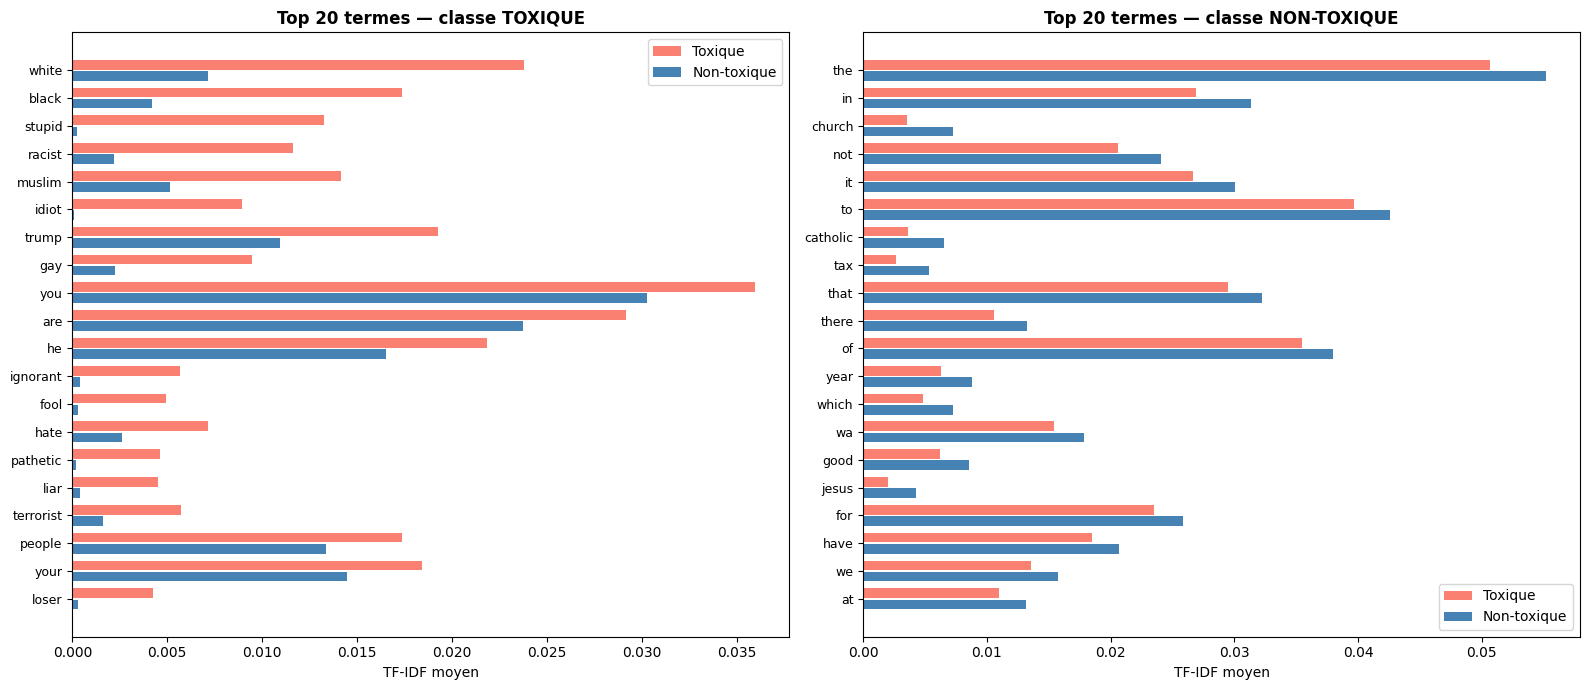

In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

# TF-IDF sur la colonne lemmatisée (vocab limité pour la lisibilité)
vectorizer = TfidfVectorizer(max_features=20_000, min_df=5, sublinear_tf=True)
tfidf_matrix = vectorizer.fit_transform(df['lemmatized_text'])
feature_names = np.array(vectorizer.get_feature_names_out())

# Score TF-IDF moyen par terme et par classe
toxic_idx     = df.index[df['is_toxic'] == 1]
non_toxic_idx = df.index[df['is_toxic'] == 0]

mean_tfidf_toxic     = np.asarray(tfidf_matrix[toxic_idx].mean(axis=0)).flatten()
mean_tfidf_non_toxic = np.asarray(tfidf_matrix[non_toxic_idx].mean(axis=0)).flatten()

# Différence : positif → plus fort en toxique, négatif → plus fort en non-toxique
diff  = mean_tfidf_toxic - mean_tfidf_non_toxic
top_n = 20

top_toxic_idx     = np.argsort(diff)[-top_n:][::-1]
top_nontoxic_idx  = np.argsort(diff)[:top_n]

print(f"=== Top {top_n} termes à fort TF-IDF UNIQUEMENT dans la classe TOXIQUE ===")
for idx in top_toxic_idx:
    print(f"  {feature_names[idx]:<25}  tox={mean_tfidf_toxic[idx]:.5f}  non_tox={mean_tfidf_non_toxic[idx]:.5f}  diff={diff[idx]:+.5f}")

print(f"\n=== Top {top_n} termes à fort TF-IDF UNIQUEMENT dans la classe NON-TOXIQUE ===")
for idx in top_nontoxic_idx:
    print(f"  {feature_names[idx]:<25}  tox={mean_tfidf_toxic[idx]:.5f}  non_tox={mean_tfidf_non_toxic[idx]:.5f}  diff={diff[idx]:+.5f}")

# Visualisation : barplots côte à côte
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, indices, title, color1, color2 in [
    (axes[0], top_toxic_idx,    f'Top {top_n} termes — classe TOXIQUE',     'salmon',    'steelblue'),
    (axes[1], top_nontoxic_idx, f'Top {top_n} termes — classe NON-TOXIQUE', 'steelblue', 'salmon'),
]:
    tox_vals     = mean_tfidf_toxic[indices]
    non_tox_vals = mean_tfidf_non_toxic[indices]
    words        = feature_names[indices]
    y = np.arange(len(words))

    ax.barh(y - 0.2, tox_vals,     height=0.35, label='Toxique',     color='salmon')
    ax.barh(y + 0.2, non_tox_vals, height=0.35, label='Non-toxique', color='steelblue')
    ax.set_yticks(y)
    ax.set_yticklabels(words, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel('TF-IDF moyen')
    ax.set_title(title, fontweight='bold')
    ax.legend()

plt.tight_layout()
plt.show()


### Analyse des groupes démographiques

Taux de toxicité global (toutes classes) : 11.34 %



,Groupe,N exemples,N toxiques,Taux de toxicité (%)
0,black,"16,420","5,181",31.55
1,homosexual_gay_or_lesbian,"12,062","3,411",28.28
2,white,"27,534","7,780",28.26
3,male,"48,870","7,355",15.05
4,female,"58,584","8,003",13.66


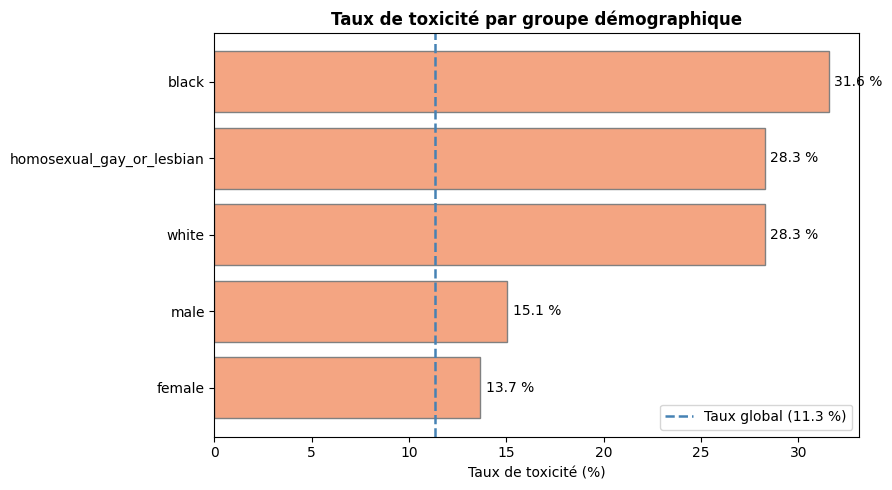

In [20]:
# Colonnes démographiques présentes dans le dataset
demo_cols = ['male', 'female', 'homosexual_gay_or_lesbian', 'black', 'white']

thr = 0.5
demo_stats = []

for col in demo_cols:
    mask = df[col].fillna(0) >= thr
    n_examples = int(mask.sum())
    n_toxic    = int(df.loc[mask, 'is_toxic'].sum())
    tox_rate   = n_toxic / n_examples if n_examples > 0 else float('nan')
    demo_stats.append({
        'Groupe': col,
        'N exemples': n_examples,
        'N toxiques': n_toxic,
        'Taux de toxicité (%)': round(tox_rate * 100, 2),
    })

# Taux de toxicité global (référence)
global_tox = df['is_toxic'].mean() * 100
demo_df = pd.DataFrame(demo_stats).sort_values('Taux de toxicité (%)', ascending=False)

print(f"Taux de toxicité global (toutes classes) : {global_tox:.2f} %\n")
display(
    demo_df.reset_index(drop=True)
    .style
    .format({'Taux de toxicité (%)': '{:.2f}', 'N exemples': '{:,}', 'N toxiques': '{:,}'})
    .bar(subset=['Taux de toxicité (%)'], color='#f4a582')
    .set_caption('Taux de toxicité par groupe démographique (seuil de mention = 0.5)')
)

# Barplot : comparaison avec le taux global
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(demo_df['Groupe'], demo_df['Taux de toxicité (%)'], color='#f4a582', edgecolor='gray')
ax.axvline(global_tox, color='steelblue', linestyle='--', linewidth=1.8,
           label=f'Taux global ({global_tox:.1f} %)')
ax.bar_label(bars, fmt='%.1f %%', padding=4, fontsize=10)
ax.set_xlabel('Taux de toxicité (%)')
ax.set_title('Taux de toxicité par groupe démographique', fontweight='bold')
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()
